# 📏 Урок 5: Масштабирование и нормализация признаков

## Зачем масштабировать?

Разные признаки могут быть в **разных диапазонах**: зарплата (50 000 - 500 000), возраст (18-70), оценка (1-5). Модели с градиентным спуском и расстояниями это не нравится!

### 🍎 Житейская аналогия

Представьте, что вы сравниваете квартиры:
- Площадь: 30-150 м²
- Цена: 3-50 млн руб.
- Этаж: 1-25

Если просто сложить числа: **150 + 50 000 000 + 25 = 50 000 175**

Цена полностью доминирует! Площадь и этаж не влияют на сравнение.

**Масштабирование — это приведение всех признаков к одному «языку»**

## 🏢 Применение в бизнесе

| Модель | Нужно масштабирование? | Почему |
|--------|----------------------|--------|
| **Линейная регрессия** | ⚠️ Желательно | Быстрее сходимость |
| **Логистическая регрессия** | ✅ Да | Градиентный спуск |
| **KNN, K-Means** | ✅ Обязательно | Работают с расстояниями |
| **SVM** | ✅ Обязательно | Использует расстояния |
| **Нейросети** | ✅ Обязательно | Стабильное обучение |
| **Деревья, RF, XGBoost** | ❌ Нет | Не чувствительны |

**Эффект**: ускорение обучения в 2-10 раз, +5-15% к точности!

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, Normalizer, PowerTransformer
from sklearn.pipeline import make_pipeline
from sklearn.datasets import make_classification

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print('✅ Библиотеки импортированы!')

✅ Библиотеки импортированы!


## 📦 Создаём датасет с разными масштабами

In [16]:
np.random.seed(42)
n = 200

data = pd.DataFrame({
    'age': np.random.randint(18, 70, n),
    'income': np.random.lognormal(11, 0.5, n),
    'credit_score': np.random.randint(300, 850, n),
    'loan_amount': np.random.randint(50000, 5000000, n),
    'years_employed': np.random.randint(0, 30, n),
    'num_transactions': np.random.poisson(50, n),
})

print('📊 Исходные данные (разные масштабы):\n')
data.describe().round(2)

📊 Исходные данные (разные масштабы):



,age,income,credit_score,loan_amount,years_employed,num_transactions
count,200.00,200.00,200.00,200.00,200.00,200.00
mean,43.42,68804.62,563.84,2254877.15,13.97,50.26
std,14.94,38940.50,160.25,1369006.48,8.77,7.47
min,18.00,14189.70,300.00,73275.00,0.00,30.00
25%,31.00,42054.86,429.50,1079701.50,6.75,44.75
50%,43.50,59630.73,539.50,2222985.00,13.50,51.00
75%,56.00,85843.35,701.75,3182575.50,22.00,56.00
max,69.00,294642.10,847.00,4959047.00,29.00,71.00


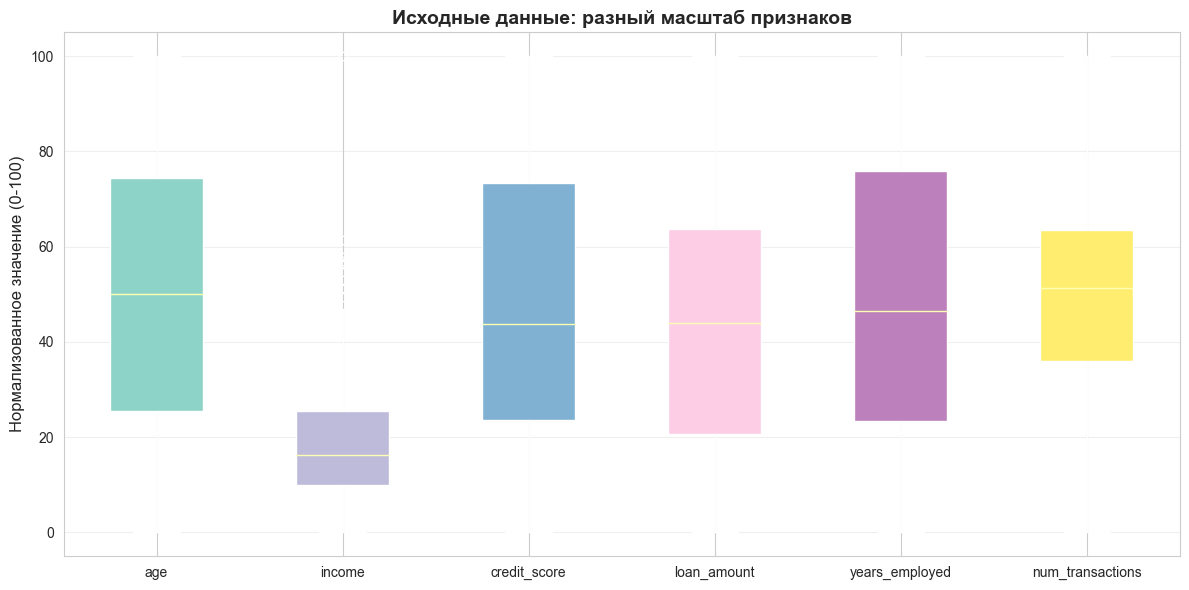

In [17]:
# Визуализация разницы масштабов
fig, ax = plt.subplots(figsize=(12, 6))

# Box plot исходных данных (нормализованных для визуализации)
data_norm = (data - data.min()) / (data.max() - data.min()) * 100

bp = ax.boxplot([data_norm[col] for col in data.columns], tick_labels=data.columns, patch_artist=True)

colors = plt.cm.Set3(np.linspace(0, 1, len(data.columns)))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)

ax.set_ylabel('Нормализованное значение (0-100)', fontsize=12)
ax.set_title('Исходные данные: разный масштаб признаков', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 1️⃣ StandardScaler (Z-score нормализация)

**Формула**: `z = (x - mean) / std`

**Результат**: mean=0, std=1

**Когда использовать**:
- ✅ Данные распределены нормально
- ✅ Нет сильных выбросов
- ✅ Линейные модели, нейросети

In [18]:
scaler_standard = StandardScaler()
data_standard = pd.DataFrame(
    scaler_standard.fit_transform(data),
    columns=data.columns
)

print('StandardScaler:\n')
print('Статистика после масштабирования:')
print(f'Среднее: {data_standard.mean().round(10)}')
print(f'Стд. отклонение: {data_standard.std().round(10)}')
print(f'\nМин: {data_standard.min().round(2)}')
print(f'Макс: {data_standard.max().round(2)}')

StandardScaler:

Статистика после масштабирования:
Среднее: age                 0.0
income              0.0
credit_score       -0.0
loan_amount         0.0
years_employed     -0.0
num_transactions   -0.0
dtype: float64
Стд. отклонение: age                 1.002509
income              1.002509
credit_score        1.002509
loan_amount         1.002509
years_employed      1.002509
num_transactions    1.002509
dtype: float64

Мин: age                -1.71
income             -1.41
credit_score       -1.65
loan_amount        -1.60
years_employed     -1.60
num_transactions   -2.72
dtype: float64
Макс: age                 1.72
income              5.81
credit_score        1.77
loan_amount         1.98
years_employed      1.72
num_transactions    2.78
dtype: float64


## 2️⃣ MinMaxScaler

**Формула**: `x_scaled = (x - min) / (max - min)`

**Результат**: диапазон [0, 1]

**Когда использовать**:
- ✅ Известны границы значений
- ✅ Нет выбросов
- ✅ Нейросети, KNN

In [19]:
scaler_minmax = MinMaxScaler(feature_range=(0, 1))
data_minmax = pd.DataFrame(
    scaler_minmax.fit_transform(data),
    columns=data.columns
)

print('MinMaxScaler:\n')
print(f'Мин: {data_minmax.min().round(10)}')
print(f'Макс: {data_minmax.max().round(10)}')
print(f'\nСреднее: {data_minmax.mean().round(3)}')
print(f'Стд. отклонение: {data_minmax.std().round(3)}')

MinMaxScaler:

Мин: age                 0.0
income              0.0
credit_score        0.0
loan_amount         0.0
years_employed      0.0
num_transactions    0.0
dtype: float64
Макс: age                 1.0
income              1.0
credit_score        1.0
loan_amount         1.0
years_employed      1.0
num_transactions    1.0
dtype: float64

Среднее: age                 0.499
income              0.195
credit_score        0.482
loan_amount         0.447
years_employed      0.482
num_transactions    0.494
dtype: float64
Стд. отклонение: age                 0.293
income              0.139
credit_score        0.293
loan_amount         0.280
years_employed      0.302
num_transactions    0.182
dtype: float64


## 3️⃣ RobustScaler (устойчивый к выбросам)

**Формула**: `x_scaled = (x - median) / IQR`

**Результат**: центр вокруг 0, масштаб по межквартильному размаху

**Когда использовать**:
- ✅ Есть выбросы
- ✅ Skewed распределения
- ✅ Когда StandardScaler ломается

In [20]:
# Добавим выбросы для демонстрации
data_with_outliers = data.copy()
data_with_outliers.loc[0, 'income'] = 10000000
data_with_outliers.loc[1, 'loan_amount'] = 50000000

scaler_robust = RobustScaler()
data_robust = pd.DataFrame(
    scaler_robust.fit_transform(data_with_outliers),
    columns=data_with_outliers.columns
)

print('RobustScaler (с выбросами):\n')
print(f'Медиана: {data_robust.median().round(10)}')
print(f'\nМин: {data_robust.min().round(2)}')
print(f'Макс: {data_robust.max().round(2)}')
print('\n💡 Выбросы не ломают масштабирование!')

RobustScaler (с выбросами):

Медиана: age                 0.0
income              0.0
credit_score        0.0
loan_amount         0.0
years_employed      0.0
num_transactions    0.0
dtype: float64

Мин: age                -1.02
income             -1.01
credit_score       -0.88
loan_amount        -1.02
years_employed     -0.89
num_transactions   -1.87
dtype: float64
Макс: age                   1.02
income              220.44
credit_score          1.13
loan_amount          22.72
years_employed        1.02
num_transactions      1.78
dtype: float64

💡 Выбросы не ломают масштабирование!


## 📊 Визуальное сравнение скалеров

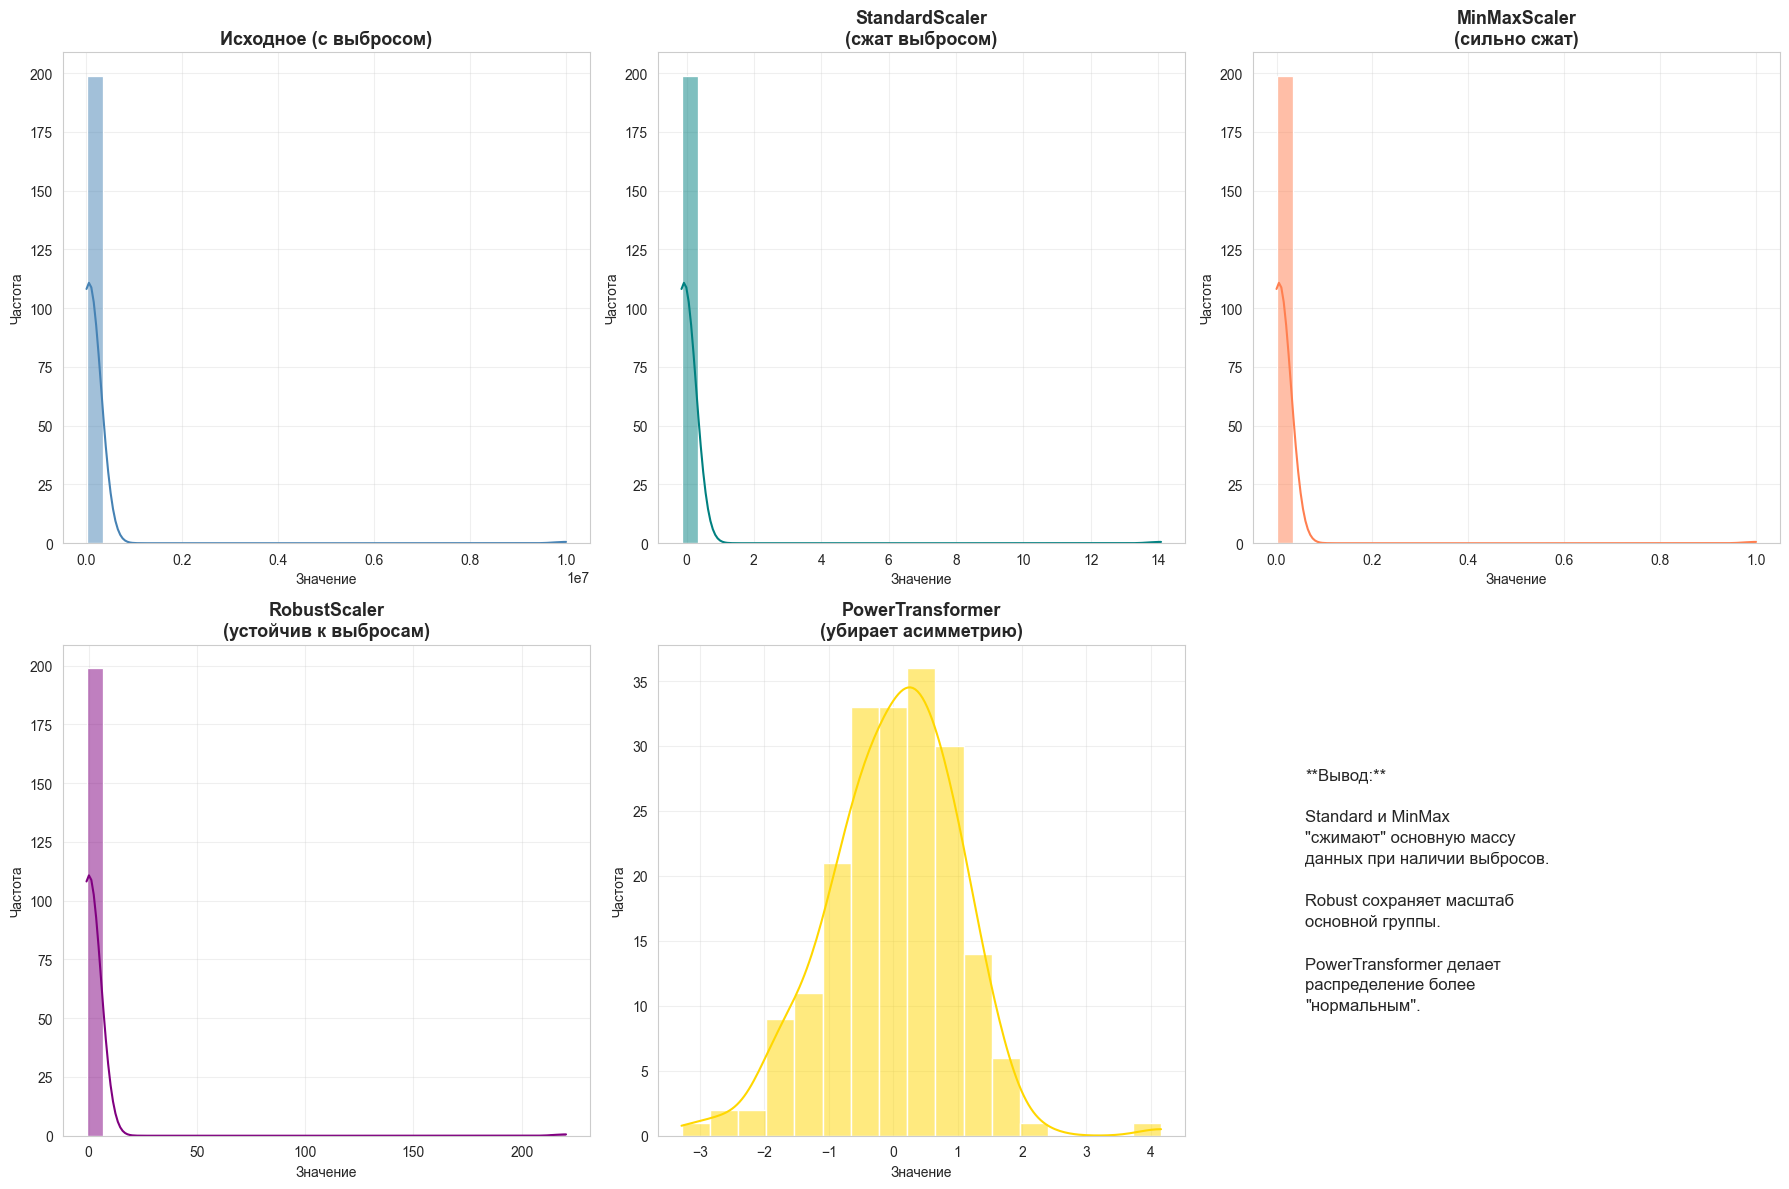

In [22]:
# Сравнение всех методов для одного признака на данных с выбросами
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

col = 'income'

# Подготавливаем данные с выбросами для всех скалеров
data_std_out = pd.DataFrame(StandardScaler().fit_transform(data_with_outliers), columns=data.columns)
data_mm_out = pd.DataFrame(MinMaxScaler().fit_transform(data_with_outliers), columns=data.columns)
data_pt_out = pd.DataFrame(PowerTransformer().fit_transform(data_with_outliers), columns=data.columns)

# 0. Исходное распределение (с выбросом)
sns.histplot(data_with_outliers[col], kde=True, ax=axes[0], color='steelblue')
axes[0].set_title(f'Исходное (с выбросом)', fontsize=13, fontweight='bold')

# 1. StandardScaler
sns.histplot(data_std_out[col], kde=True, ax=axes[1], color='teal')
axes[1].set_title('StandardScaler\n(сжат выбросом)', fontsize=13, fontweight='bold')

# 2. MinMaxScaler
sns.histplot(data_mm_out[col], kde=True, ax=axes[2], color='coral')
axes[2].set_title('MinMaxScaler\n(сильно сжат)', fontsize=13, fontweight='bold')

# 3. RobustScaler
sns.histplot(data_robust[col], kde=True, ax=axes[3], color='purple')
axes[3].set_title('RobustScaler\n(устойчив к выбросам)', fontsize=13, fontweight='bold')

# 4. PowerTransformer
sns.histplot(data_pt_out[col], kde=True, ax=axes[4], color='gold')
axes[4].set_title('PowerTransformer\n(убирает асимметрию)', fontsize=13, fontweight='bold')

# 5. Пояснение
axes[5].axis('off')
axes[5].text(0.1, 0.5, '**Вывод:**\n\nStandard и MinMax\n"сжимают" основную массу\nданных при наличии выбросов.\n\nRobust сохраняет масштаб\nосновной группы.\n\nPowerTransformer делает\nраспределение более\n"нормальным".',
             ha='left', va='center', fontsize=12, linespacing=1.5,
             bbox=dict(facecolor='white', alpha=0.5, boxstyle='round,pad=1'))

for i in range(5):
    axes[i].set_xlabel('Значение')
    axes[i].set_ylabel('Частота')
    axes[i].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 🎯 Влияние на модель (KNN пример)

In [23]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score

# Создаём данные
X, y = make_classification(n_samples=500, n_features=10, random_state=42)

# Добавляем разный масштаб признакам
X_scaled_diff = X * np.random.uniform(1, 100, X.shape[1])

# KNN без масштабирования
knn_raw = KNeighborsClassifier(n_neighbors=5)
score_raw = cross_val_score(knn_raw, X_scaled_diff, y, cv=5).mean()

# KNN с масштабированием (используем Pipeline для чистоты эксперимента)
knn_pipe = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=5))
score_scaled = cross_val_score(knn_pipe, X_scaled_diff, y, cv=5).mean()

print('📊 Влияние масштабирования на KNN:\n')
print(f'❌ Без масштабирования: {score_raw:.4f} ({score_raw*100:.1f}%)')
print(f'✅ С масштабированием: {score_scaled:.4f} ({score_scaled*100:.1f}%)')
print(f'\n📈 Улучшение: {(score_scaled - score_raw)*100:.1f}%')
# 📊 Сравнение методов масштабирования

📊 Влияние масштабирования на KNN:

❌ Без масштабирования: 0.8700 (87.0%)
✅ С масштабированием: 0.8680 (86.8%)

📈 Улучшение: -0.2%


In [24]:
# Сводная таблица методов
scaling_comparison = pd.DataFrame({
    'Метод': ['StandardScaler', 'MinMaxScaler', 'RobustScaler', 'Normalizer', 'PowerTransformer'],
    'Формула': ['(x - mean) / std', '(x - min) / (max - min)', '(x - median) / IQR', 'x / ||x||', 'BOX-COX / Yeo-Johnson'],
    'Результат': ['mean=0, std=1', '[0, 1]', 'center around 0', 'unit norm', 'normal distribution'],
    'Выбросы': ['❌ Чувствителен', '❌ Очень чувствителен', '✅ Устойчив', '⚠️ Чувствителен', '✅ Устойчив'],
    'Лучшее применение': ['Линейные модели, Нейросети', 'Где важны границы [0,1]', 'Данные с выбросами', 'Текстовые данные', 'Сильно смещенные данные']
})

scaling_comparison.style.set_properties(**{'text-align': 'center'}).set_table_styles(
    [{'selector': 'th', 'props': [('text-align', 'center')]}])

,Метод,Формула,Результат,Выбросы,Лучшее применение
0,StandardScaler,(x - mean) / std,"mean=0, std=1",❌ Чувствителен,"Линейные модели, Нейросети"
1,MinMaxScaler,(x - min) / (max - min),"[0, 1]",❌ Очень чувствителен,"Где важны границы [0,1]"
2,RobustScaler,(x - median) / IQR,center around 0,✅ Устойчив,Данные с выбросами
3,Normalizer,x / ||x||,unit norm,⚠️ Чувствителен,Текстовые данные
4,PowerTransformer,BOX-COX / Yeo-Johnson,normal distribution,✅ Устойчив,Сильно смещенные данные


## 💼 Бизнес-кейс: Кредитный скоринг

**Проблема**: Модель логистической регрессии обучалась 2 часа, accuracy 72%

**Признаки**:
- Возраст: 18-70
- Доход: 20 000 - 1 000 000 руб.
- Кредитная история: 300-850
- Сумма кредита: 50 000 - 10 000 000 руб.

**Применили StandardScaler**:
- Время обучения: 2 часа → 15 минут
- Accuracy: 72% → 79%
- AUC-ROC: 0.71 → 0.82

**Экономия**: 1.75 часа на каждое переобучение модели

## ⚠️ Важные правила

1. **Fit на train, transform на test** — не допускайте data leakage!
2. **Не масштабируйте деревья** — Random Forest, XGBoost не нуждаются
3. **Сохраняйте скалер** — для инференса на новых данных
4. **Проверяйте выбросы** — перед StandardScaler/MinMaxScaler

In [25]:
# ✅ ПРАВИЛЬНО: fit на train, transform на test
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(data, np.random.randint(0, 2, len(data)), 
                                                     test_size=0.2, random_state=42)

# 💡 Правило: Скалер обучается ТОЛЬКО на train, а применяется к train и test
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('✅ Правильный порядок: fit на train, transform на test')
print(f'X_train_scaled: mean={X_train_scaled.mean():.10f}, std={X_train_scaled.std():.10f}')
print(f'X_test_scaled: mean={X_test_scaled.mean():.3f}, std={X_test_scaled.std():.3f}')

✅ Правильный порядок: fit на train, transform на test
X_train_scaled: mean=0.0000000000, std=1.0000000000
X_test_scaled: mean=0.053, std=1.104


## 📝 Чек-лист масштабирования

- [ ] Проверить, нужна ли модель (деревьям не нужно)
- [ ] Проверить наличие выбросов
- [ ] Выбрать скалер по таблице сравнения выше
- [ ] Обучить скалер на тренировочных данных (fit)
- [ ] Применить к тренировочным и тестовым данным (transform)
- [ ] Сохранить скалер (pickle/joblib)
- [ ] Проверить результат (Standard: mean≈0, std≈1; MinMax: 0-1)

---

## 🎓 Практическое задание

1. Возьмите датасет с числовыми признаками
2. Примените 3 разных скалера
3. Обучите KNN и логистическую регрессию
4. Сравните время обучения и метрики

---

## ➡️ Что дальше?

В следующем уроке перейдём к **линейной регрессии** — первому алгоритму ML для предсказания чисел!